# Figure 4 — Kingman, Real Sweep

Real-data analogue of Figure 3. Same two-panel layout (recovery curves +
$\hat p^*(n)$ scaling), but the similarity matrix is generated from JC69
sequences on Kingman trees (`interactive_run.py` sweep), and the tree-feature
parameters $(\eta, \rho)$ are **estimated from each $M$** rather than preset.

**Bound under test (non-balanced CBM):**
$$
p > \frac{C \cdot \eta(1+\eta)^3 }{(\rho - \eta\, S_{\mathrm{out}}^{\max})^2} \frac{\ln n}{n}
$$
with $\rho = (S_{\mathrm{in}}^{\max} - S_{\mathrm{out}}^{\max}) - (S_{\mathrm{out}}^{\max} - S_{\mathrm{out}}^{\min})$.

**Sweep already done.** This notebook only loads results and the cached $M$/$v_{\text{pop}}$;
no experiments are re-run.

## Cell 1 — Configuration

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT.parent != ROOT and not (ROOT / "setup.py").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT / "sub_sampled_fielder_vec"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis.theoretical_interpretation.utils import (
    imbalance_eta, n_min, structural_margin_rho, estimate_features_from_M,
    coherence_mu, compute_top_eigenpairs, spectral_gap,
    find_threshold_p_star,
)
from src.cache_io import experiment_data as _cache_scope, make_key as _make_key

RUNS_ROOT = PROJECT_ROOT / "results" / "runs"
SEQ_LEN   = 10_000
RECOVERY_THRESHOLD = 0.95

# Datasets to compare. Each has its own (tree_model, µ, N grid, run dir),
# so most cells loop over this list and key everything by ds["name"]
# (which must be unique). cache_dir lookup still uses tree_model + mu.
DATASETS = [
    dict(
        name="kingman_mean",
        tree_model="kingman_mean",
        mu=0.1,
        run_dir=RUNS_ROOT / "kingman_mean" / "uniform"
            / "20260501-194101-kingman_mean_n500-8000_mu_0p1_uniform",
        n_values=[500, 1000, 2000, 4000, 6000, 8000],
        marker="o",
    ),
    dict(
        name="kingman_mu0.3",
        tree_model="kingman",
        mu=0.3,
        run_dir=RUNS_ROOT / "kingman" / "uniform"
            / "20260501-153602-kingman_n512-4096_mu_0p3_uniform",
        n_values=[512, 1024, 2048, 4096],
        marker="s",
    ),
    dict(
        name="kingman_mu0.1",
        tree_model="kingman",
        mu=0.1,
        run_dir=RUNS_ROOT / "kingman" / "uniform"
            / "20260505-222310-kingman_n500-8000_mu_0p1_uniform",
        # n=8000 still running — leave it out for now.
        n_values=[500, 1000, 2000, 4000, 6000],
        marker="^",
    ),
]

def cache_dir_for(tree_model: str, mu: float, n: int) -> Path:
    """Resolve the on-disk cache dir via the same key builder the runner uses.

    Mirrors ``src.utils.persistent_cache._get_cache_key`` defaults: pop_size=1.0,
    seq=JC69, num_classes=4. Layout is ``<project>/cache/experiment_data/<key>/``.
    """
    key = _make_key(
        n=int(n),
        L=int(SEQ_LEN),
        mu=float(mu),
        tree=str(tree_model),
        seq="JC69",
        pop_size=1.0,
        num_classes=4,
    )
    return _cache_scope.path(key)

def results_path_for(run_dir: Path, n: int) -> Path:
    return run_dir / f"n{n}_L{SEQ_LEN}" / "results.json"

for ds in DATASETS:
    for n in ds["n_values"]:
        rp = results_path_for(ds["run_dir"], n)
        cd = cache_dir_for(ds["tree_model"], ds["mu"], n)
        assert rp.exists(), f"missing results: {rp}"
        assert cd.exists(),  f"missing cache:   {cd}"
    print(f"{ds['name']:18s} tree={ds['tree_model']:13s} µ={ds['mu']}  n={ds['n_values']}")


kingman_mean       tree=kingman_mean  µ=0.1  n=[500, 1000, 2000, 4000, 6000, 8000]
kingman_mu0.3      tree=kingman       µ=0.3  n=[512, 1024, 2048, 4096]
kingman_mu0.1      tree=kingman       µ=0.1  n=[500, 1000, 2000, 4000, 6000]


## Cell 2 — Load the sweep results

`results.json` is column-oriented: a flat `columns` list and a list of `rows`,
one row per p-value. We keep `partition_agreement_M` (already in $[0, 100]$)
and convert to a fraction in $[0, 1]$ for thresholding.

In [2]:
frames = []
for ds in DATASETS:
    for n in ds["n_values"]:
        with open(results_path_for(ds["run_dir"], n)) as f:
            payload = json.load(f)
        df_n = pd.DataFrame(payload["rows"], columns=payload["columns"])
        df_n = df_n[["p", "partition_agreement_M"]].copy()
        df_n["agreement"] = df_n["partition_agreement_M"] / 100.0
        df_n["n"] = n
        df_n["name"] = ds["name"]
        frames.append(df_n)

df_agg = (
    pd.concat(frames, ignore_index=True)
      .sort_values(["name", "n", "p"])
      .reset_index(drop=True)
)
print(f"df_agg shape: {df_agg.shape}")
df_agg.groupby(["name", "n"])["partition_agreement_M"].agg(["min", "max"])


df_agg shape: (300, 5)


min    max
name          n                     
kingman_mean  500   52.600000  100.0
              1000  50.700000  100.0
              2000  50.550000  100.0
              4000  50.025000  100.0
              6000  50.516667  100.0
              8000  50.087500  100.0
kingman_mu0.1 500   51.200000  100.0
              1000  50.900000  100.0
              2000  51.100000  100.0
              4000  51.800000  100.0
              6000  50.050000  100.0
kingman_mu0.3 512   52.343750  100.0
              1024  51.562500  100.0
              2048  50.146484  100.0
              4096  50.170898  100.0

## Cell 3 — Load cached $M$ and reference Fiedler $v_{\text{pop}}$

These are produced by the experiment runner during the original sweep and
stored under `src/cache/<key>/`. We don't recompute them — just load the
`.npz` files.

In [3]:
matrices = {}   # ds["name"] -> {n: (M, v_pop)}
for ds in DATASETS:
    for n in ds["n_values"]:
        cdir = cache_dir_for(ds["tree_model"], ds["mu"], n)
        M     = np.load(cdir / "similarity_matrix.npz")["similarity_matrix"]
        v_pop = np.load(cdir / "fiedler_ref.npz")["fiedler_ref"]
        matrices[(ds["name"], n)] = (M, v_pop)
        print(f"{ds['name']:18s} n={n:>4}: M.shape={M.shape}, "
              f"v_pop range=[{v_pop.min():+.4f}, {v_pop.max():+.4f}]")


kingman_mean       n= 500: M.shape=(500, 500), v_pop range=[-0.0833, +0.0249]
kingman_mean       n=1000: M.shape=(1000, 1000), v_pop range=[-0.1631, +0.0065]
kingman_mean       n=2000: M.shape=(2000, 2000), v_pop range=[-0.1850, +0.0032]
kingman_mean       n=4000: M.shape=(4000, 4000), v_pop range=[-0.0160, +0.0165]
kingman_mean       n=6000: M.shape=(6000, 6000), v_pop range=[-0.0323, +0.0056]
kingman_mean       n=8000: M.shape=(8000, 8000), v_pop range=[-0.0313, +0.0042]
kingman_mu0.3      n= 512: M.shape=(512, 512), v_pop range=[-0.1765, +0.0145]
kingman_mu0.3      n=1024: M.shape=(1024, 1024), v_pop range=[-0.0261, +0.0382]
kingman_mu0.3      n=2048: M.shape=(2048, 2048), v_pop range=[-0.0293, +0.0188]
kingman_mu0.3      n=4096: M.shape=(4096, 4096), v_pop range=[-0.0177, +0.0171]
kingman_mu0.1      n= 500: M.shape=(500, 500), v_pop range=[-0.0267, +0.0782]
kingman_mu0.1      n=1000: M.shape=(1000, 1000), v_pop range=[-0.0175, +0.0590]
kingman_mu0.1      n=2000: M.shape=(2000, 2000

## Cell 4 — Estimate tree-feature parameters from each $M$

Use the sign of $v_{\text{pop}}$ to bipartition the rows/columns of $M$
into two clans, then read off in-block / cross-block similarity statistics:

- $\eta$ = `imbalance_eta(n_1, n_2)`
- $\rho$ = `structural_margin_rho(S_{\mathrm{in}}^{\max}, S_{\mathrm{out}}^{\max}, S_{\mathrm{out}}^{\min})`
- margin = $\rho - \eta \, S_{\mathrm{out}}^{\max}$  (must be $> 0$ for the bound to be finite)

In [4]:
feature_rows = []
for ds in DATASETS:
    for n in ds["n_values"]:
        M, v_pop = matrices[(ds["name"], n)]
        feats = estimate_features_from_M(M, v_pop)
        feats["n"] = n
        feats["name"] = ds["name"]
        feats["tree_model"] = ds["tree_model"]
        feats["mu"] = ds["mu"]
        feature_rows.append(feats)

df_features = pd.DataFrame(feature_rows)[
    ["name", "tree_model", "mu", "n", "n1", "n2", "eta",
     "S_in_max", "S_out_max", "S_out_min", "rho", "margin"]
]

bad = df_features[df_features["margin"] <= 0]
if not bad.empty:
    print("⚠  Margin ≤ 0 (non-balanced CBM bound is singular) at:")
    for _, row in bad.iterrows():
        print(f"    {row['name']:18s} n={int(row['n']):>4}: "
              f"η={row['eta']:7.3f}, ρ={row['rho']:.4f}, "
              f"margin={row['margin']:.4f} (η·S_out_max={row['eta']*row['S_out_max']:.4f} > ρ)")
    print("   These rows will be excluded from the C-fit and the theory overlay.")

df_features


⚠  Margin ≤ 0 (non-balanced CBM bound is singular) at:
    kingman_mean       n=1000: η= 24.641, ρ=0.7864, margin=-4.1081 (η·S_out_max=4.8945 > ρ)
    kingman_mean       n=2000: η= 49.000, ρ=0.7660, margin=-9.7898 (η·S_out_max=10.5558 > ρ)
    kingman_mean       n=6000: η=  5.424, ρ=0.7686, margin=-0.3705 (η·S_out_max=1.1391 > ρ)
    kingman_mean       n=8000: η=  7.273, ρ=0.7681, margin=-0.7934 (η·S_out_max=1.5616 > ρ)
    kingman_mu0.3      n= 512: η=  9.449, ρ=0.8809, margin=-0.0778 (η·S_out_max=0.9587 > ρ)
    kingman_mu0.1      n= 500: η=  2.968, ρ=0.7335, margin=-0.0003 (η·S_out_max=0.7338 > ρ)
    kingman_mu0.1      n=2000: η= 17.349, ρ=0.7694, margin=-3.0558 (η·S_out_max=3.8253 > ρ)
   These rows will be excluded from the C-fit and the theory overlay.


,name,tree_model,mu,n,n1,n2,eta,S_in_max,S_out_max,S_out_min,rho,margin
0,kingman_mean,kingman_mean,0.1,500,384,116,3.310345,1.0,0.223280,0.207896,0.761335,0.022200
1,kingman_mean,kingman_mean,0.1,1000,961,39,24.641026,1.0,0.198632,0.183638,0.786375,-4.108109
2,kingman_mean,kingman_mean,0.1,2000,1960,40,49.000000,1.0,0.215425,0.196867,0.766017,-9.789784
3,kingman_mean,kingman_mean,0.1,4000,1977,2023,1.023268,1.0,0.214707,0.191767,0.762354,0.542652
4,kingman_mean,kingman_mean,0.1,6000,5066,934,5.423983,1.0,0.210008,0.188593,0.768576,-0.370505
5,kingman_mean,kingman_mean,0.1,8000,7033,967,7.273009,1.0,0.214707,0.197544,0.768131,-0.793432
6,kingman_mu0.3,kingman,0.3,512,463,49,9.448980,1.0,0.101456,0.083798,0.880887,-0.077764
7,kingman_mu0.3,kingman,0.3,1024,411,613,1.491484,1.0,0.001717,0.000538,0.997105,0.994545
8,kingman_mu0.3,kingman,0.3,2048,1205,843,1.429419,1.0,0.169663,0.143878,0.804551,0.562031
9,kingman_mu0.3,kingman,0.3,4096,2080,2016,1.031746,1.0,0.231777,0.208598,0.745044,0.505908


## Cell 5 — Top-3 eigenpairs of $L = D - M$ per $n$

For each $n$ we form the unnormalized Laplacian $L = D - M$ and extract its
three smallest eigenpairs via `compute_top_eigenpairs`. The Fiedler eigenvector
$v^{(1)}$ defines the partition; $\lambda_2$ and $\lambda_3$ feed the spectral
gap $\Delta\lambda$. Mirrors Figure 2 Cell 4.


In [5]:
eig_per = {}
for ds in DATASETS:
    for n in ds["n_values"]:
        M, _ = matrices[(ds["name"], n)]
        L = np.diag(M.sum(axis=1)) - M
        eigvals, eigvecs = compute_top_eigenpairs(L, k=3)
        eig_per[(ds["name"], n)] = dict(
            eigvals=eigvals,
            U=eigvecs[:, :2],
            v1=eigvecs[:, 1],
        )
        print(f"{ds['name']:18s} n={n:5d}: "
              f"λ1={eigvals[0]:.4f}, λ2={eigvals[1]:.4f}, λ3={eigvals[2]:.4f}")


kingman_mean       n=  500: λ1=-0.0000, λ2=107.3610, λ3=171.2967
kingman_mean       n= 1000: λ1=0.0000, λ2=190.9126, λ3=220.1495
kingman_mean       n= 2000: λ1=-0.0000, λ2=412.7755, λ3=435.5348
kingman_mean       n= 4000: λ1=-0.0000, λ2=810.6614, λ3=1298.8076
kingman_mean       n= 6000: λ1=-0.0000, λ2=1189.4993, λ3=1432.7687
kingman_mean       n= 8000: λ1=0.0000, λ2=1649.4005, λ3=2345.8019
kingman_mu0.3      n=  512: λ1=0.0000, λ2=46.1807, λ3=52.4223
kingman_mu0.3      n= 1024: λ1=-0.0000, λ2=1.2571, λ3=25.7586
kingman_mu0.3      n= 2048: λ1=0.0000, λ2=316.4935, λ3=350.8578
kingman_mu0.3      n= 4096: λ1=0.0000, λ2=904.6857, λ3=991.6082
kingman_mu0.1      n=  500: λ1=0.0000, λ2=118.6472, λ3=191.6294
kingman_mu0.1      n= 1000: λ1=-0.0000, λ2=109.0543, λ3=199.1724
kingman_mu0.1      n= 2000: λ1=0.0000, λ2=430.5586, λ3=509.8501
kingman_mu0.1      n= 4000: λ1=0.0000, λ2=914.2132, λ3=1436.8685
kingman_mu0.1      n= 6000: λ1=0.0000, λ2=1931.6163, λ3=2683.8441


## Cell 6 — Linalg features $\mu(U)$, $\lambda_2$, $\Delta\lambda$ vs CBM predictions

Three relations from Thesis V.03 evaluated on real $M$:

1. $\mu(U) \approx (1+\eta)/2$ (rank-2 coherence; identity on flat CBM)
2. $\lambda_2 \approx n \cdot S_{\text{out}}^{\max}$ (Fiedler eigenvalue; identity on flat CBM)
3. Lemma 0.4: $\Delta\lambda \ge n_{\min}\,(\rho - \eta\,S_{\text{out}}^{\max})$ (lower bound; should hold strictly)

The first two collapse to identities only when $M$ is exactly flat-CBM, so on
real Kingman data they read as approximations. The third is an inequality and
is the main object of interest.


In [6]:
mu_emp = []
lambda2_emp = []
delta_emp = []
mu_pred = []
lambda2_pred = []
gap_lb = []
for _, row in df_features.iterrows():
    n = int(row["n"])
    info = eig_per[(row["name"], n)]
    mu_emp.append(coherence_mu(info["U"]))
    lambda2_emp.append(float(info["eigvals"][1]))
    delta_emp.append(spectral_gap(info["eigvals"]))

    eta = row["eta"]
    nmin = n_min(int(row["n1"]), int(row["n2"]))
    mu_pred.append((1.0 + eta) / 2.0)
    lambda2_pred.append(n * row["S_out_max"])
    gap_lb.append(nmin * (row["rho"] - eta * row["S_out_max"]))

df_features["mu"] = mu_emp
df_features["mu_pred"] = mu_pred
df_features["lambda2"] = lambda2_emp
df_features["lambda2_pred"] = lambda2_pred
df_features["delta_lambda"] = delta_emp
df_features["gap_lb"] = gap_lb

df_features[
    ["name", "n", "eta", "mu", "mu_pred",
     "lambda2", "lambda2_pred",
     "delta_lambda", "gap_lb"]
]


,name,n,eta,mu,mu_pred,lambda2,lambda2_pred,delta_lambda,gap_lb
0,kingman_mean,500,3.310345,2.235945,2.155172,107.361018,111.640148,63.935675,2.575219
1,kingman_mean,1000,24.641026,13.803006,12.820513,190.912607,198.631513,29.236942,-160.216265
2,kingman_mean,2000,49.000000,34.706826,25.000000,412.775530,430.849024,22.759229,-391.591344
3,kingman_mean,4000,1.023268,1.045703,1.011634,810.661412,858.826361,488.146191,1072.822655
4,kingman_mean,6000,5.423983,3.621924,3.211991,1189.499334,1260.049634,243.269409,-346.051917
5,kingman_mean,8000,7.273009,4.408142,4.136505,1649.400496,1717.652722,696.401419,-767.248835
6,kingman_mu0.3,512,9.448980,8.471923,5.224490,46.180665,51.945220,6.241622,-3.810454
7,kingman_mu0.3,1024,1.491484,1.246683,1.245742,1.257088,1.757702,24.501467,408.757944
8,kingman_mu0.3,2048,1.429419,1.380367,1.214709,316.493495,347.470706,34.364336,473.792028
9,kingman_mu0.3,4096,1.031746,1.138722,1.015873,904.685678,949.359705,86.922489,1019.911275


## Cell 7 — Three-panel identity scatter (real-data analogue of Figure 2 Cell 12)

Each panel plots the empirical linalg feature against its CBM prediction.
Panels 1–2 should cluster near the $y=x$ identity if the real $M$ is close
to flat-CBM; panel 3 (Lemma 0.4) is a lower bound, so empirical points should
lie **above** the identity line.


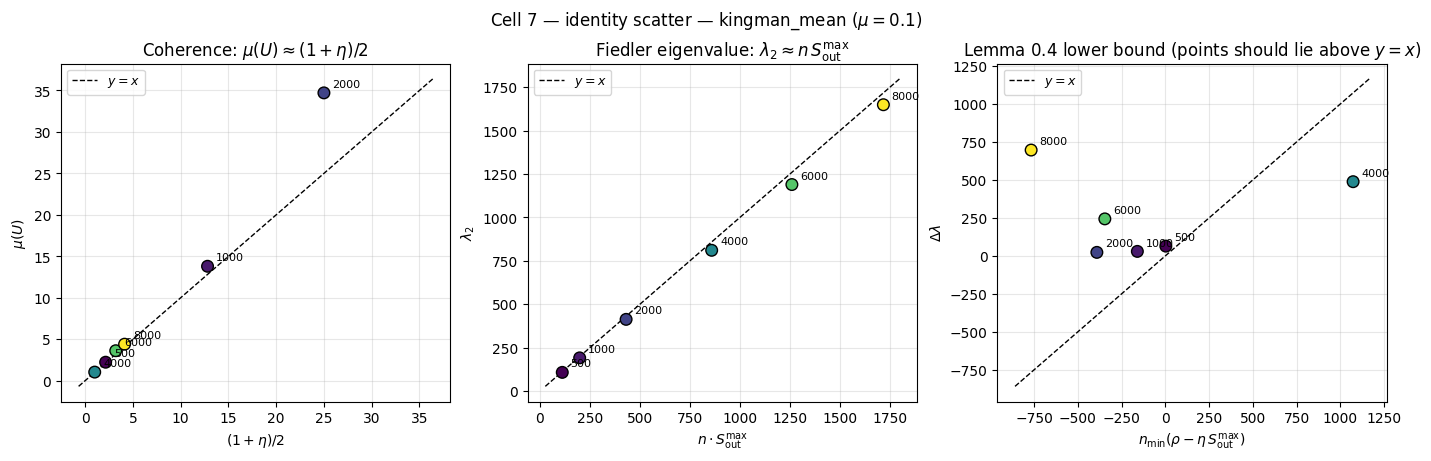

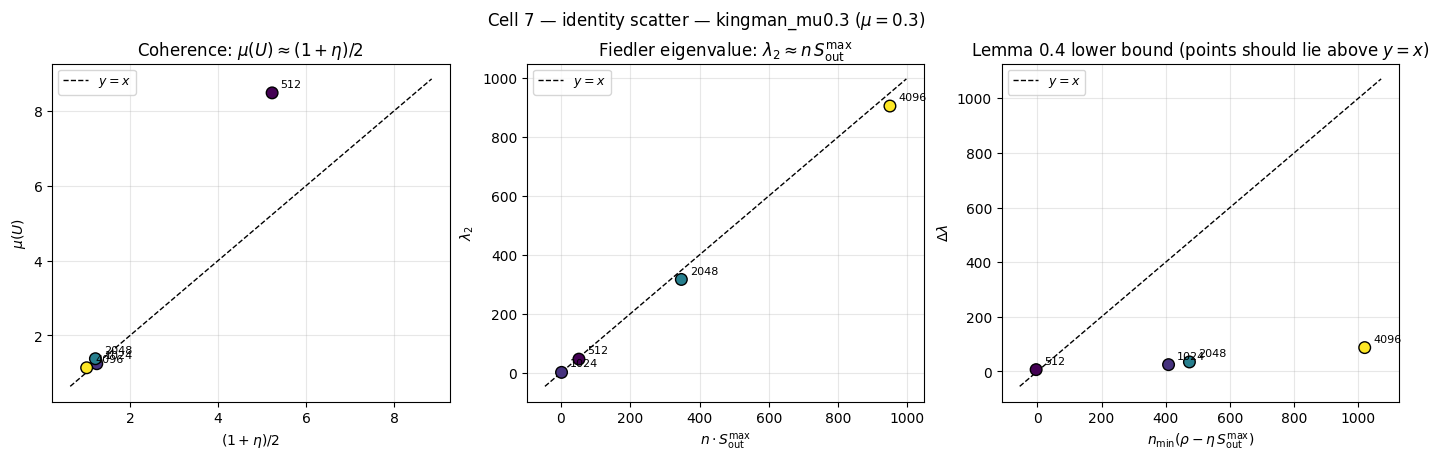

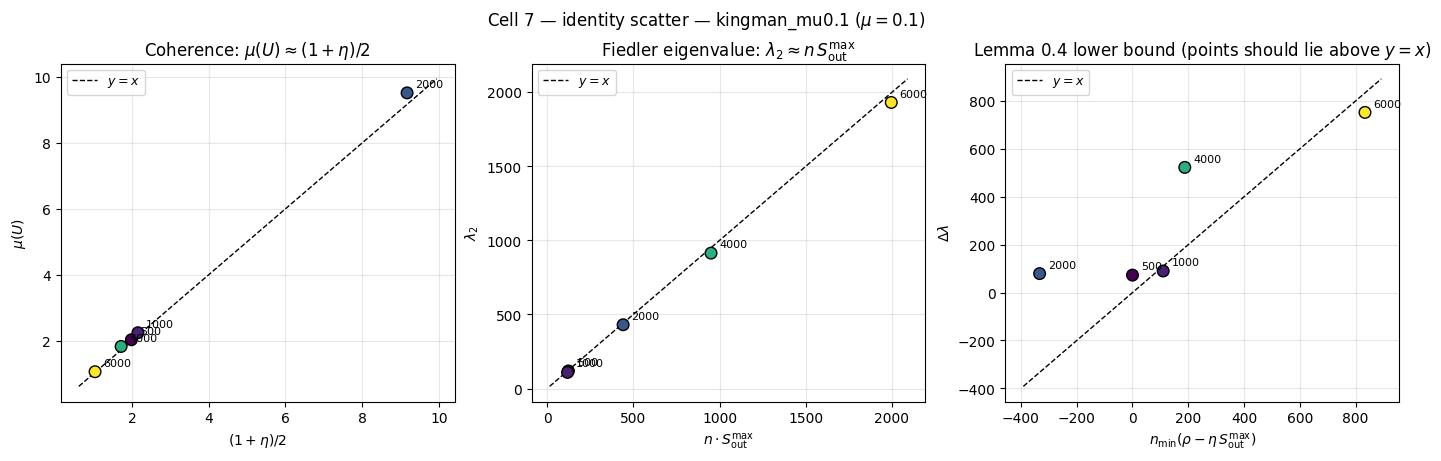

In [7]:
panels = [
    ("mu_pred", "mu", r"$(1+\eta)/2$", r"$\mu(U)$",
     r"Coherence: $\mu(U) \approx (1+\eta)/2$"),
    ("lambda2_pred", "lambda2", r"$n \cdot S_{\mathrm{out}}^{\max}$", r"$\lambda_2$",
     r"Fiedler eigenvalue: $\lambda_2 \approx n\,S_{\mathrm{out}}^{\max}$"),
    ("gap_lb", "delta_lambda",
     r"$n_{\min}(\rho - \eta\,S_{\mathrm{out}}^{\max})$", r"$\Delta\lambda$",
     r"Lemma 0.4 lower bound (points should lie above $y=x$)"),
]

# One 3-panel identity figure per dataset.
for ds in DATASETS:
    name = ds["name"]
    sub = df_features[df_features["name"] == name]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
    fig.suptitle(fr"Cell 7 — identity scatter — {name} ($\mu={ds['mu']}$)")

    for ax, (xcol, ycol, xlbl, ylbl, title) in zip(axes, panels):
        ax.scatter(sub[xcol], sub[ycol],
                   c=sub["n"], cmap="viridis",
                   s=70, edgecolor="k", zorder=3)
        for _, r in sub.iterrows():
            ax.annotate(int(r["n"]), (r[xcol], r[ycol]),
                        textcoords="offset points", xytext=(6, 4), fontsize=8)
        x = sub[xcol].to_numpy()
        y = sub[ycol].to_numpy()
        lo = float(min(x.min(), y.min()))
        hi = float(max(x.max(), y.max()))
        pad = 0.05 * (hi - lo if hi > lo else 1.0)
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="$y = x$")
        ax.set_xlabel(xlbl)
        ax.set_ylabel(ylbl)
        ax.set_title(title)
        ax.grid(alpha=0.3)
        ax.legend(loc="best", fontsize=9)

    plt.show()


## Cell 9 — Empirical $\hat p^*(n)$ from `partition_agreement_M`

`partition_agreement_M` is symmetric under bipartition label-flip, so it
bottoms out near 50% (random guess) at intermediate p-values rather than
monotonically rising. `find_threshold_p_star` returns the *smallest* p with
agreement $\ge 0.95$. We additionally print the curve to confirm there's no
spurious low-p crossing.

In [8]:
p_star_per = {}
for ds in DATASETS:
    for n in ds["n_values"]:
        sub = df_agg[(df_agg.name == ds["name"]) & (df_agg.n == n)].sort_values("p")
        p_star = find_threshold_p_star(
            sub["p"].to_numpy(),
            sub["agreement"].to_numpy(),
            threshold=RECOVERY_THRESHOLD,
        )
        p_star_per[(ds["name"], n)] = p_star
        crossing = int((sub["agreement"] >= RECOVERY_THRESHOLD).sum())
        print(f"{ds['name']:18s} n={n:>4}: "
              f"p_star={p_star},  #(p with agreement ≥ 0.95) = {crossing}")

df_features["p_star"] = df_features.apply(
    lambda r: p_star_per[(r["name"], int(r["n"]))], axis=1
)
df_features


kingman_mean       n= 500: p_star=0.08858667904100823,  #(p with agreement ≥ 0.95) = 6
kingman_mean       n=1000: p_star=0.08858667904100823,  #(p with agreement ≥ 0.95) = 6
kingman_mean       n=2000: p_star=0.002976351441631319,  #(p with agreement ≥ 0.95) = 7
kingman_mean       n=4000: p_star=0.012742749857031334,  #(p with agreement ≥ 0.95) = 10
kingman_mean       n=6000: p_star=0.0206913808111479,  #(p with agreement ≥ 0.95) = 9
kingman_mean       n=8000: p_star=0.012742749857031334,  #(p with agreement ≥ 0.95) = 10
kingman_mu0.3      n= 512: p_star=0.08858667904100823,  #(p with agreement ≥ 0.95) = 6
kingman_mu0.3      n=1024: p_star=0.012742749857031334,  #(p with agreement ≥ 0.95) = 10
kingman_mu0.3      n=2048: p_star=0.05455594781168514,  #(p with agreement ≥ 0.95) = 7
kingman_mu0.3      n=4096: p_star=0.03359818286283781,  #(p with agreement ≥ 0.95) = 8
kingman_mu0.1      n= 500: p_star=0.08858667904100823,  #(p with agreement ≥ 0.95) = 6
kingman_mu0.1      n=1000: p_star=0.0

,name,tree_model,mu,n,n1,n2,eta,S_in_max,S_out_max,S_out_min,rho,margin,mu_pred,lambda2,lambda2_pred,delta_lambda,gap_lb,p_star
0,kingman_mean,kingman_mean,2.235945,500,384,116,3.310345,1.0,0.223280,0.207896,0.761335,0.022200,2.155172,107.361018,111.640148,63.935675,2.575219,0.088587
1,kingman_mean,kingman_mean,13.803006,1000,961,39,24.641026,1.0,0.198632,0.183638,0.786375,-4.108109,12.820513,190.912607,198.631513,29.236942,-160.216265,0.088587
2,kingman_mean,kingman_mean,34.706826,2000,1960,40,49.000000,1.0,0.215425,0.196867,0.766017,-9.789784,25.000000,412.775530,430.849024,22.759229,-391.591344,0.002976
3,kingman_mean,kingman_mean,1.045703,4000,1977,2023,1.023268,1.0,0.214707,0.191767,0.762354,0.542652,1.011634,810.661412,858.826361,488.146191,1072.822655,0.012743
4,kingman_mean,kingman_mean,3.621924,6000,5066,934,5.423983,1.0,0.210008,0.188593,0.768576,-0.370505,3.211991,1189.499334,1260.049634,243.269409,-346.051917,0.020691
5,kingman_mean,kingman_mean,4.408142,8000,7033,967,7.273009,1.0,0.214707,0.197544,0.768131,-0.793432,4.136505,1649.400496,1717.652722,696.401419,-767.248835,0.012743
6,kingman_mu0.3,kingman,8.471923,512,463,49,9.448980,1.0,0.101456,0.083798,0.880887,-0.077764,5.224490,46.180665,51.945220,6.241622,-3.810454,0.088587
7,kingman_mu0.3,kingman,1.246683,1024,411,613,1.491484,1.0,0.001717,0.000538,0.997105,0.994545,1.245742,1.257088,1.757702,24.501467,408.757944,0.012743
8,kingman_mu0.3,kingman,1.380367,2048,1205,843,1.429419,1.0,0.169663,0.143878,0.804551,0.562031,1.214709,316.493495,347.470706,34.364336,473.792028,0.054556
9,kingman_mu0.3,kingman,1.138722,4096,2080,2016,1.031746,1.0,0.231777,0.208598,0.745044,0.505908,1.015873,904.685678,949.359705,86.922489,1019.911275,0.033598


## Cell 10 — Theoretical scale and fit constant $C$

$$
\text{theory\_scale}(n) \;=\; \frac{\eta(n)\,(1+\eta(n))^3 \,\ln n}{n \cdot \text{margin}(n)^2}
$$
$$
C \;=\; \operatorname{median}_{n \,\in\, \text{valid}} \frac{\hat p^*(n)}{\text{theory\_scale}(n)}
$$
Rows with non-positive margin or `NaN` $\hat p^*$ are excluded from the median.

In [9]:
df_features["theory_scale"] = (
    df_features["eta"] * (1 + df_features["eta"]) ** 3 * np.log(df_features["n"])
    / (df_features["n"] * df_features["margin"] ** 2)
)

C_per_dataset = {}
for name, sub in df_features.groupby("name"):
    valid = sub[(sub["margin"] > 0) & sub["p_star"].notna()]
    if valid.empty:
        C_per_dataset[name] = float("nan")
        print(f"⚠  {name}: no valid rows for C-fit — leaving C = NaN.")
    else:
        ratios = valid["p_star"] / valid["theory_scale"]
        C_per_dataset[name] = float(np.median(ratios))
        print(f"{name:18s}: C = {C_per_dataset[name]:.4g}  "
              f"(median over {len(valid)} valid n: "
              + ", ".join(str(int(x)) for x in valid['n'].tolist()) + ")")

df_features


kingman_mean      : C = 0.1068  (median over 2 valid n: 500, 4000)
kingman_mu0.1     : C = 0.004127  (median over 3 valid n: 1000, 4000, 6000)
kingman_mu0.3     : C = 0.2258  (median over 3 valid n: 1024, 2048, 4096)


,name,tree_model,mu,n,n1,n2,eta,S_in_max,S_out_max,S_out_min,rho,margin,mu_pred,lambda2,lambda2_pred,delta_lambda,gap_lb,p_star,theory_scale
0,kingman_mean,kingman_mean,2.235945,500,384,116,3.310345,1.0,0.223280,0.207896,0.761335,0.022200,2.155172,107.361018,111.640148,63.935675,2.575219,0.088587,6.685605e+03
1,kingman_mean,kingman_mean,13.803006,1000,961,39,24.641026,1.0,0.198632,0.183638,0.786375,-4.108109,12.820513,190.912607,198.631513,29.236942,-160.216265,0.088587,1.700270e+02
2,kingman_mean,kingman_mean,34.706826,2000,1960,40,49.000000,1.0,0.215425,0.196867,0.766017,-9.789784,25.000000,412.775530,430.849024,22.759229,-391.591344,0.002976,2.428819e+02
3,kingman_mean,kingman_mean,1.045703,4000,1977,2023,1.023268,1.0,0.214707,0.191767,0.762354,0.542652,1.011634,810.661412,858.826361,488.146191,1072.822655,0.012743,5.967787e-02
4,kingman_mean,kingman_mean,3.621924,6000,5066,934,5.423983,1.0,0.210008,0.188593,0.768576,-0.370505,3.211991,1189.499334,1260.049634,243.269409,-346.051917,0.020691,1.518751e+01
5,kingman_mean,kingman_mean,4.408142,8000,7033,967,7.273009,1.0,0.214707,0.197544,0.768131,-0.793432,4.136505,1649.400496,1717.652722,696.401419,-767.248835,0.012743,7.348851e+00
6,kingman_mu0.3,kingman,8.471923,512,463,49,9.448980,1.0,0.101456,0.083798,0.880887,-0.077764,5.224490,46.180665,51.945220,6.241622,-3.810454,0.088587,2.171918e+04
7,kingman_mu0.3,kingman,1.246683,1024,411,613,1.491484,1.0,0.001717,0.000538,0.997105,0.994545,1.245742,1.257088,1.757702,24.501467,408.757944,0.012743,1.578592e-01
8,kingman_mu0.3,kingman,1.380367,2048,1205,843,1.429419,1.0,0.169663,0.143878,0.804551,0.562031,1.214709,316.493495,347.470706,34.364336,473.792028,0.054556,2.415652e-01
9,kingman_mu0.3,kingman,1.138722,4096,2080,2016,1.031746,1.0,0.231777,0.208598,0.745044,0.505908,1.015873,904.685678,949.359705,86.922489,1019.911275,0.033598,6.865689e-02


## Cell 11 — Two-panel figure

**Left:** `partition_agreement_M` vs $p$ per $n$ (viridis), red dashed 95%
threshold.  
**Right:** $\hat p^*(n)$ vs $n$ (log-log) with the theoretical curve
$\;C\cdot\eta(n)(1+\eta(n))^3\ln n / [n\,\text{margin}(n)^2]\;$
evaluated per-$n$ (because $\eta$ and $\rho$ are estimated, not fixed).

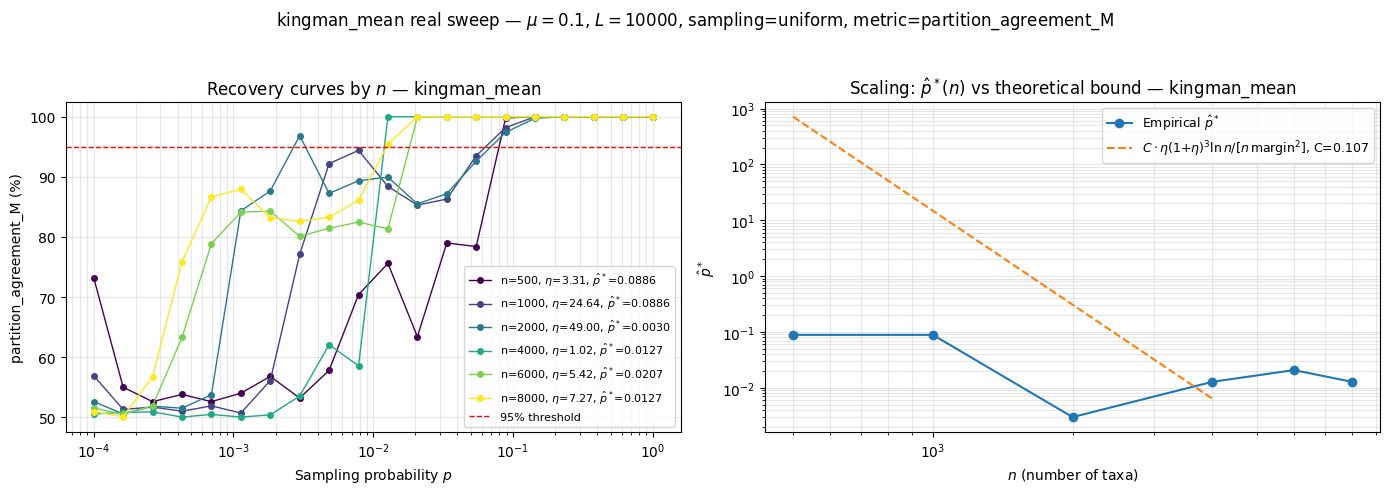

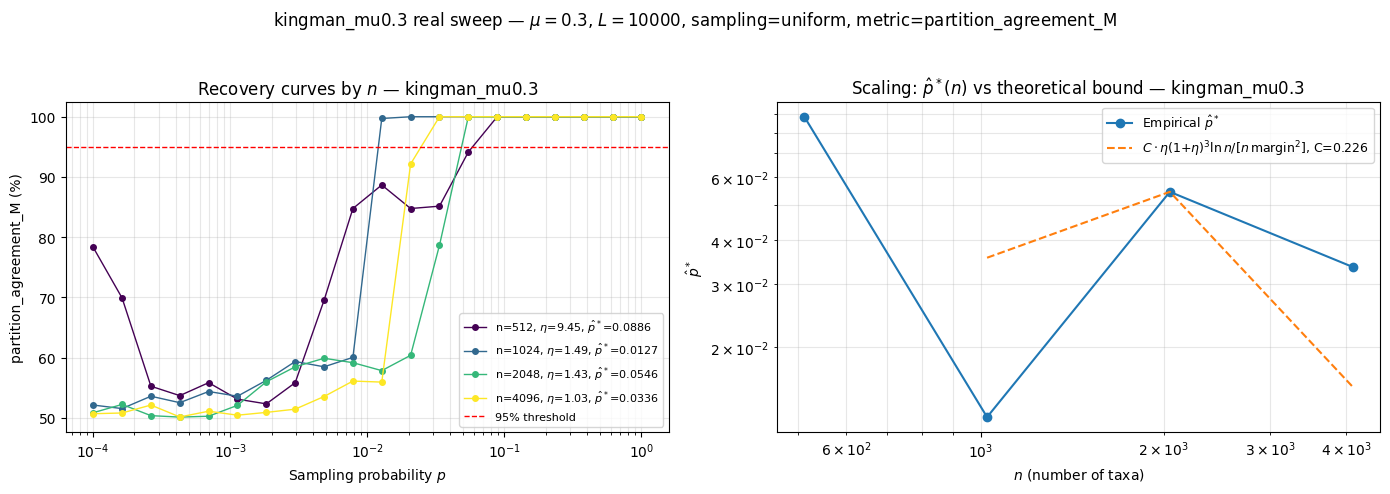

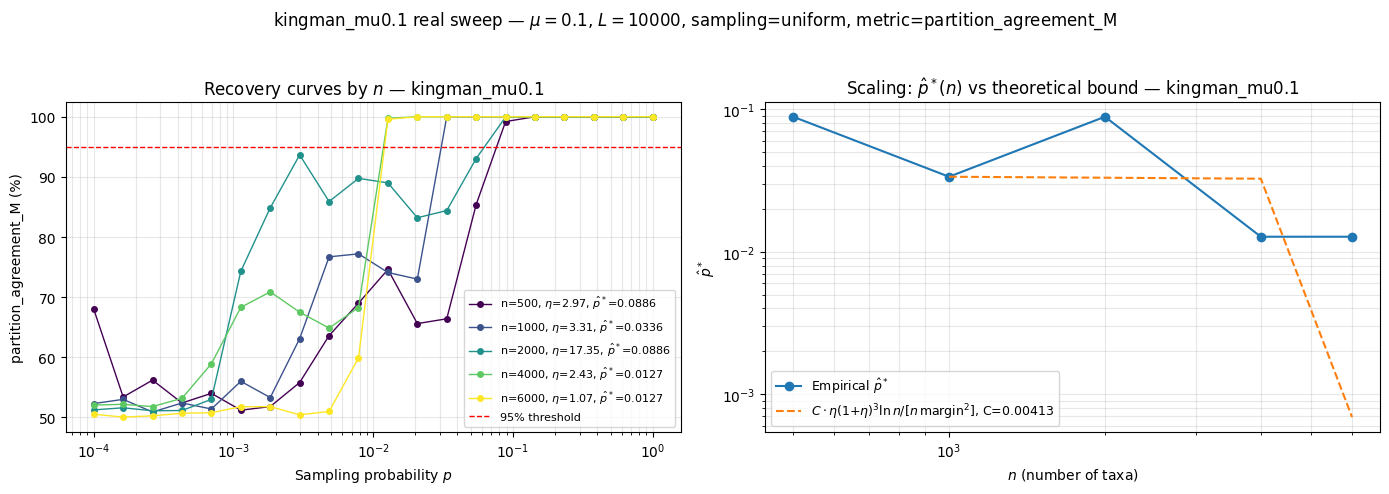

In [10]:
# One two-panel figure per dataset; rendered inline only (not saved).
for ds in DATASETS:
    name = ds["name"]
    sub_features = df_features[df_features["name"] == name]
    sub_agg = df_agg[df_agg["name"] == name]
    if sub_features.empty or sub_agg.empty:
        continue

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        fr"{name} real sweep — $\mu={ds['mu']}$, $L={SEQ_LEN}$, sampling=uniform, "
        fr"metric=partition_agreement_M"
    )

    # ---------- Left: recovery curves ----------
    cmap = plt.get_cmap("viridis")
    n_values = ds["n_values"]
    n_to_color = {n: cmap(i / max(1, len(n_values) - 1)) for i, n in enumerate(n_values)}

    for n in n_values:
        sub = sub_agg[sub_agg.n == n].sort_values("p")
        p_star = p_star_per[(name, n)]
        p_star_label = (f"{p_star:.4f}"
                        if p_star is not None and np.isfinite(p_star)
                        else "n/a")
        eta_n = sub_features.loc[sub_features.n == n, "eta"].iloc[0]
        ax_l.plot(
            sub["p"], sub["partition_agreement_M"],
            "-o", color=n_to_color[n], ms=4, lw=1,
            label=fr"n={n}, $\eta$={eta_n:.2f}, $\hat p^*$={p_star_label}",
        )

    ax_l.axhline(100.0 * RECOVERY_THRESHOLD, color="red", ls="--", lw=1,
                 label=f"{int(RECOVERY_THRESHOLD * 100)}% threshold")
    ax_l.set_xscale("log")
    ax_l.set_xlabel(r"Sampling probability $p$")
    ax_l.set_ylabel("partition_agreement_M (%)")
    ax_l.set_title(fr"Recovery curves by $n$ — {name}")
    ax_l.legend(fontsize=8, loc="lower right")
    ax_l.grid(True, which="both", alpha=0.3)

    # ---------- Right: p*(n) scaling ----------
    df_emp = sub_features.dropna(subset=["p_star"]).sort_values("n")
    if not df_emp.empty:
        ax_r.plot(df_emp["n"], df_emp["p_star"], "-o",
                  label=r"Empirical $\hat p^*$")

    df_thy = sub_features[sub_features["margin"] > 0].sort_values("n")
    C = C_per_dataset.get(name, float("nan"))
    if np.isfinite(C) and not df_thy.empty:
        theory = C * df_thy["theory_scale"]
        ax_r.plot(
            df_thy["n"], theory, "--",
            label=(
                r"$C\cdot\eta(1{+}\eta)^3 \ln n / [n\,\mathrm{margin}^2]$"
                f", C={C:.3g}"
            ),
        )

    ax_r.set_xscale("log")
    ax_r.set_yscale("log")
    ax_r.set_xlabel(r"$n$ (number of taxa)")
    ax_r.set_ylabel(r"$\hat p^*$")
    ax_r.set_title(fr"Scaling: $\hat p^*(n)$ vs theoretical bound — {name}")
    ax_r.legend(fontsize=9)
    ax_r.grid(True, which="both", alpha=0.3)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
